In [ ]:
# ===========================================================================
# ACOUSTIC FEATURE ANALYSIS - interactive driver
#
# All extraction/plotting logic lives in src/; this notebook only calls it
# and stores results, matching notebooks/01's convention. Split out of the
# old notebooks/01_data_pipeline.ipynb (EDA) and notebooks/03_praat_analysis.ipynb
# (Praat extraction/statistics) into one feature-analysis notebook, since both
# are exploratory acoustic-feature work, not pipeline construction.
#
#   src/preprocessing.py   MFCC extraction (13 coeff + delta + delta-delta)
#   src/vad.py              Silero VAD (leading/trailing trim, fallback, stats)
#   src/praat.py            per-feature-group extraction (F0, jitter, shimmer,
#                            HNR, CPPS, formants, intensity, speech-rate/pause/
#                            voice-break proxies) + extract_praat_features_batch()
#   src/visualization.py    EDA figures, Praat box plots/summary, feature
#                            correlation heatmap
#
# Features are extracted from the ORIGINAL audio, not the VAD-trimmed/
# zero-padded window the Deep/Acoustic pathways train on - jitter, shimmer,
# HNR, and formants are only meaningful on natural speech. See ROADMAP.md
# Phase 4 for the full plan and src/praat.py's module docstring for the
# speech-rate/pause-duration caveat (UA-Speech utterances are single
# isolated words, not continuous speech). Stage 2 below validates VAD itself
# (raw vs. VAD-processed waveform/MFCC); Praat's own pitch/point-process
# voicing logic (not VAD) is what decides which frames its jitter/shimmer/HNR
# statistics trust - VAD stats (outputs/vad_stats.csv, notebooks/01_data_pipeline.ipynb
# Stage 9) are available only as an independent sanity check, not a second
# voicing decision.
# ===========================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.console import print_header, print_kv
from src.training.data import load_manifest

config.ensure_directories()

df_m6 = load_manifest()

print_header("Acoustic Feature Analysis")
print_kv("Manifest", config.MANIFEST_PATH)
print_kv("Utterances", len(df_m6))

In [ ]:
# STAGE 2 - VAD validation: raw waveform, detected speech region, the
# resulting VAD-processed waveform, and MFCC before/after VAD - for five
# examples chosen to each demonstrate a specific VAD behaviour rather than
# one-per-severity-band:
#   1. normal duration       - a typical, single speech segment
#   2. long trailing silence - VAD had to trim the most trailing dead air
#   3. long leading silence  - VAD had to trim the most leading dead air
#   4. internal pauses       - multiple detected speech segments, so VAD's
#                              "merge nearby regions" behaviour is visible
#                              (preserved, not collapsed into one block)
#   5. weak/low-energy dysarthric - lowest detected speech_ratio among
#                              dysarthric speakers, i.e. the case most likely
#                              to be mistaken for silence
# This is the direct answer to the supervisor's "large near-constant region
# after the speech" observation: notebooks/01_data_pipeline.ipynb Stage 9
# measured the root cause quantitatively (mostly fixed-window padding after a
# short isolated-word utterance, not merely un-trimmed trailing silence);
# this cell shows it visually, before vs. after Silero VAD (src/vad.py)
# replaced the old leading-only torchaudio VAD trim.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import vad as vad_module
from src.preprocessing import (_load_resampled, _pad_or_truncate, build_mfcc_transform,
                               extract_mfcc_features, load_and_preprocess_with_stats)
from src.console import print_status, progress

mfcc_transform = build_mfcc_transform()


def _plot_vad_validation(axes_row, row, category: str) -> dict:
    """Draw the 4-panel [raw+VAD region | processed waveform | MFCC before |
    MFCC after] validation for one utterance into an existing 1x4 Axes row.
    Returns the VAD stats dict, for the caller's summary printout."""
    raw_waveform, sr = _load_resampled(row["Filepath"])
    raw_np = raw_waveform[0].numpy()
    trimmed_waveform, vad_stats = vad_module.apply_vad(raw_waveform, sr)
    processed_waveform, _ = _pad_or_truncate(trimmed_waveform)

    t_raw = np.arange(len(raw_np)) / sr
    axes_row[0].plot(t_raw, raw_np, linewidth=0.5, color="steelblue")
    if not vad_stats["fallback_used"]:
        speech_start_s = vad_stats["leading_trimmed_s"]
        speech_end_s = t_raw[-1] - vad_stats["trailing_trimmed_s"]
        axes_row[0].axvspan(speech_start_s, speech_end_s, color="orange", alpha=0.25)
    axes_row[0].set_title(f"[{category}] {row['Speaker_ID']} ({row['Severity']}) — raw + VAD region")
    axes_row[0].set_xlabel("s")

    t_proc = np.arange(processed_waveform.shape[1]) / sr
    axes_row[1].plot(t_proc, processed_waveform[0].numpy(), linewidth=0.5, color="seagreen")
    axes_row[1].set_title(f"VAD-processed ({vad_stats['speech_ratio']:.1%} speech, "
                          f"{vad_stats['num_segments']} segment(s))")
    axes_row[1].set_xlabel("s")

    old_waveform, _ = _pad_or_truncate(raw_waveform)
    old_mfcc = extract_mfcc_features(old_waveform, mfcc_transform)[0].numpy()
    axes_row[2].imshow(old_mfcc, aspect="auto", origin="lower", cmap="viridis")
    axes_row[2].set_title("MFCC — before VAD (raw, padded)")

    new_mfcc = extract_mfcc_features(processed_waveform, mfcc_transform)[0].numpy()
    axes_row[3].imshow(new_mfcc, aspect="auto", origin="lower", cmap="viridis")
    axes_row[3].set_title("MFCC — after VAD")

    return vad_stats


# A moderate stratified sample (not the full 21k-utterance manifest — this
# cell only needs enough spread to find one clear example per category, and
# a full-dataset VAD pass belongs to notebooks/01_data_pipeline.ipynb Stage 9
# / src.preprocessing.compute_vad_stats_batch instead, not here). Reuses
# outputs/vad_stats.csv if it's already been computed there.
if config.VAD_STATS_PATH.exists():
    vad_stats_sample = pd.read_csv(config.VAD_STATS_PATH).merge(
        df_m6[["Filename", "Filepath", "Group", "Severity"]], on="Filename", how="inner")
else:
    sample_df = (df_m6.groupby("Speaker_ID", group_keys=False)
                .apply(lambda g: g.sample(min(15, len(g)), random_state=config.DEFAULT_SEED)))
    records = []
    for row in progress(sample_df.itertuples(index=False), "Sampling VAD stats for example selection",
                        total=len(sample_df), unit="utt"):
        _, _, stats = load_and_preprocess_with_stats(row.Filepath)
        records.append({"Filename": row.Filename, "Filepath": row.Filepath,
                        "Group": row.Group, "Severity": row.Severity, **stats})
    vad_stats_sample = pd.DataFrame(records)

not_fallback = vad_stats_sample[~vad_stats_sample["fallback_used"]]
dysarthric = not_fallback[not_fallback["Group"] == "Dysarthric Patient"]

category_picks = {
    "normal duration": not_fallback.iloc[
        (not_fallback["speech_ratio"] - not_fallback["speech_ratio"].median()).abs().argsort()[:1]],
    "long trailing silence": not_fallback.nlargest(1, "trailing_trimmed_s"),
    "long leading silence": not_fallback.nlargest(1, "leading_trimmed_s"),
    "internal pauses": not_fallback.nlargest(1, "num_segments"),
    "weak/low-energy dysarthric": (dysarthric if len(dysarthric) else not_fallback).nsmallest(1, "speech_ratio"),
}

example_rows = [(category, df_m6[df_m6["Filename"] == picks.iloc[0]["Filename"]].iloc[0])
                for category, picks in category_picks.items() if len(picks)]

fig, axes = plt.subplots(len(example_rows), 4, figsize=(18, 3.2 * len(example_rows)))
example_stats = []

for i, (category, row) in enumerate(example_rows):
    vad_stats = _plot_vad_validation(axes[i], row, category)
    example_stats.append({"Category": category, "Speaker_ID": row["Speaker_ID"],
                          "Severity": row["Severity"], **vad_stats})

    # Also saved per-example so any single case can be linked to directly.
    per_example_fig, per_example_axes = plt.subplots(1, 4, figsize=(18, 3.2))
    _plot_vad_validation(per_example_axes, row, category)
    per_example_fig.tight_layout()
    per_example_path = (config.FIGURE_DIR /
                        f"vad_validation_{category.replace(' ', '_').replace('/', '-')}"
                        f"_{row['Speaker_ID']}_{Path(row['Filename']).stem}.png")
    per_example_fig.savefig(per_example_path, dpi=150, bbox_inches="tight")
    plt.close(per_example_fig)

fig.tight_layout()
vad_validation_path = config.FIGURE_DIR / "vad_validation_examples.png"
fig.savefig(vad_validation_path, dpi=200, bbox_inches="tight")
plt.show()

print_header("VAD Validation")
print_kv("Examples (5 VAD-behaviour categories)", len(example_rows))
print_kv("Combined figure", vad_validation_path)
print_kv("Per-example figures", f"{config.FIGURE_DIR}/vad_validation_<category>_<speaker>_<file>.png")
print_status(f"{int(vad_stats_sample['fallback_used'].sum())}/{len(vad_stats_sample)} sampled utterances "
            "fell back to the original (untrimmed) waveform",
            ok=(vad_stats_sample["fallback_used"].sum() == 0))
pd.DataFrame(example_stats)[["Category", "Speaker_ID", "Severity", "original_duration_s",
                             "speech_duration_s", "speech_ratio", "num_segments", "fallback_used"]]

In [4]:
# STAGE 3 - Extract all FEATURE_COLUMNS Praat features for every utterance in the manifest:
#   pitch        f0 mean/max/min/std/range        (std+range = monopitch)
#   perturbation jitter x4, shimmer x4            (vocal-fold instability)
#   noise        hnr mean/std/min                 (breathiness, roughness)
#   voice qual cpps                             (breathy/dysphonic voice quality)
#   articulation f1/f2/f3 mean+std, f2_f1_ratio   (vowel-space centralization)
#   loudness     intensity mean/max/min/std       (loudness control)
#   rhythm       speech_rate, pause_duration, voice_breaks
#
# Cached to outputs/praat_features.csv - safe to re-run this cell, later runs
# load the cache instead of recomputing ~21k files (~25-30 minutes uncached).
from src.praat import extract_praat_features_batch

praat_features = extract_praat_features_batch(df_m6, cache_path=config.PRAAT_FEATURES_PATH)
praat_features.head()


─── Praat acoustic analysis — 31 features x 21,381 utterances ────────────────
  Extracting Praat features        100%|███████████████████| 21381/21381 [1:41:24<00:00,  3.51utt/s]
  [ ✓ ] 21,381/21,381 utterances measured
  Praat features cached ................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\praat_features.csv


,Filename,Speaker_ID,Group,Severity,f0_mean,f0_max,f0_min,f0_std,f0_range,jitter_local,...,f2_std,f3_std,f2_f1_ratio,intensity_mean,intensity_max,intensity_min,intensity_std,speech_rate,pause_duration,voice_breaks
0,CF02_B1_C10_M6.wav,CF02,Healthy Control,N/A (Control),193.462009,241.038510,170.309902,20.411507,70.728608,0.012261,...,258.975777,467.806150,2.491959,71.962337,80.532605,53.441594,9.503012,57.437009,1.284713,0
1,CF02_B1_C11_M6.wav,CF02,Healthy Control,N/A (Control),192.398801,241.389726,172.630745,16.913252,68.758981,0.014648,...,142.251705,490.963197,2.603749,73.018384,80.796028,53.807974,9.968247,51.897660,1.503148,1
2,CF02_B1_C12_M6.wav,CF02,Healthy Control,N/A (Control),172.436509,248.643831,101.332359,36.898560,147.311472,0.022340,...,136.687581,249.048179,2.685872,71.016511,81.895293,55.862818,7.692538,36.762195,1.575784,7
3,CF02_B1_C13_M6.wav,CF02,Healthy Control,N/A (Control),199.640942,263.300030,115.279526,38.549255,148.020504,0.020910,...,203.527513,262.834234,2.751127,72.219952,82.619616,57.284906,7.267551,31.907078,1.500607,1
4,CF02_B1_C14_M6.wav,CF02,Healthy Control,N/A (Control),221.608963,234.114783,210.264932,8.364335,23.849850,0.013245,...,147.354487,313.339269,2.470660,66.155601,79.634530,53.509744,5.812253,12.687468,1.710969,0


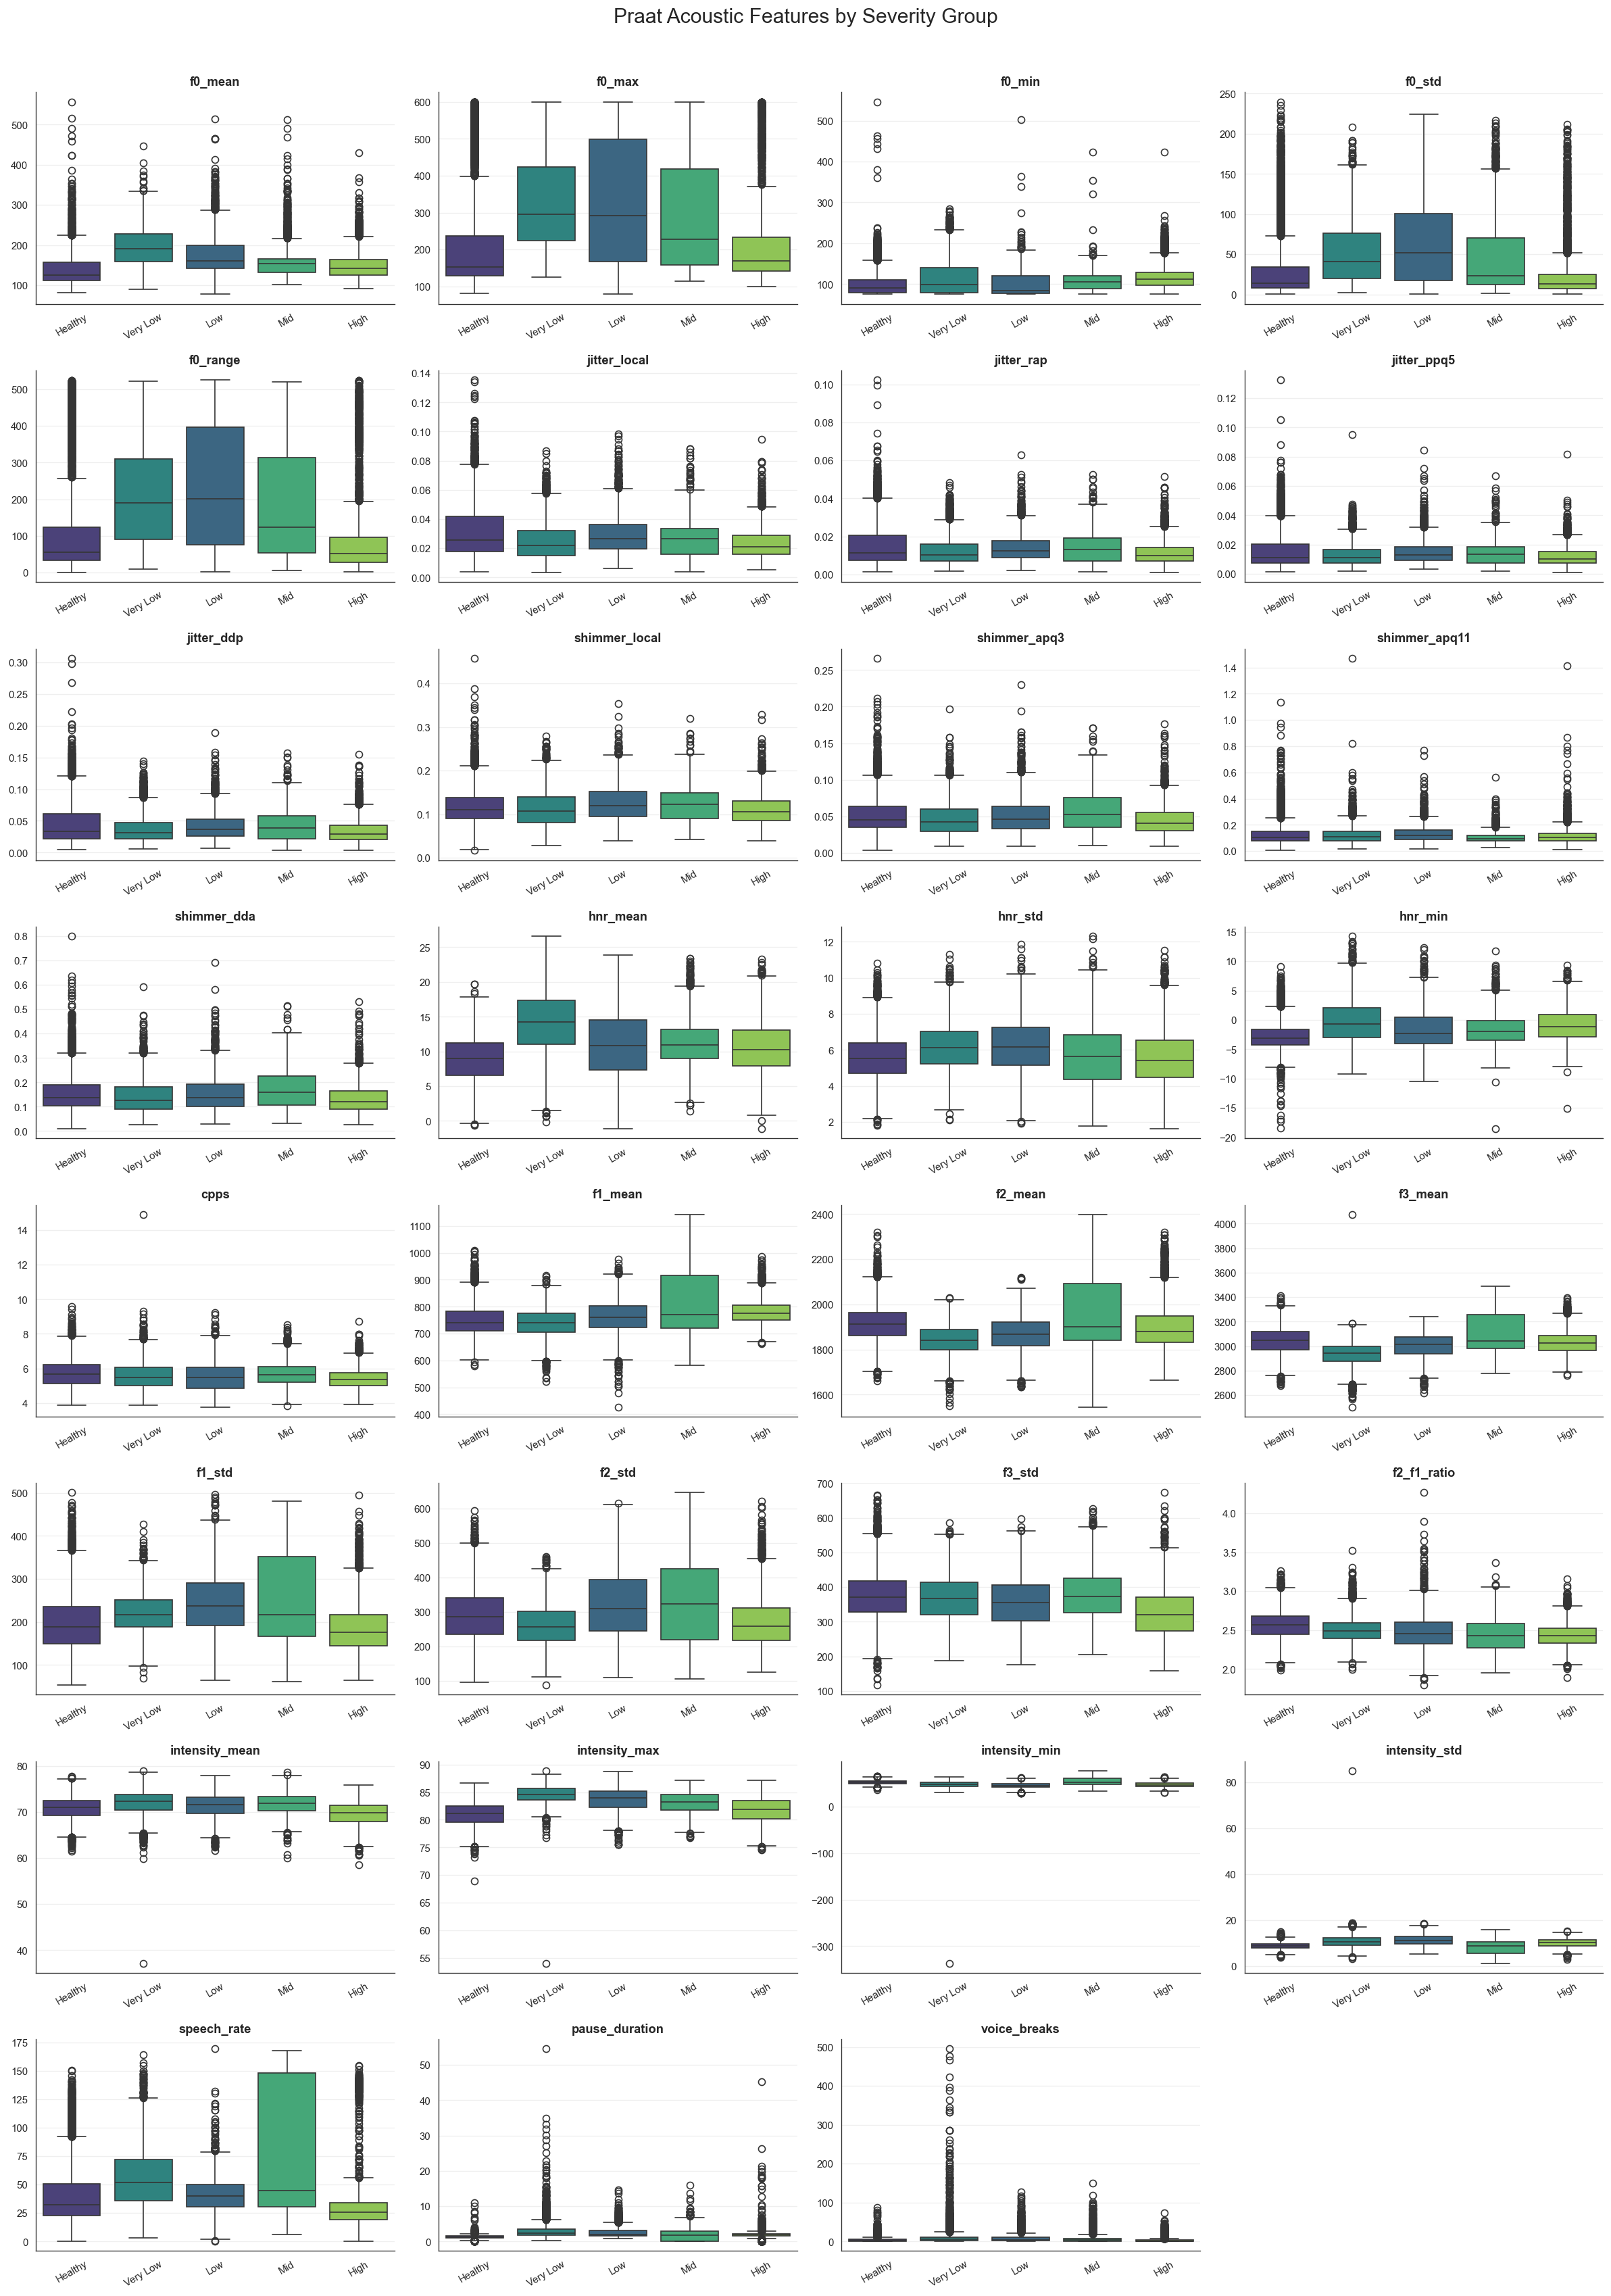


══════════════════════════════════════════════════════════════════════════════
  SEVERITY GROUP COMPARISON
══════════════════════════════════════════════════════════════════════════════
  Figure .................................. C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\figures\praat_severity_comparison.png
  Group summary table ..................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\metrics\praat_severity_group_summary.csv


f0_mean                 f0_max                  f0_min  \
                   mean        std        mean         std        mean   
Group_Order                                                              
Healthy      137.035917  37.455284  201.939571  113.217247  100.769559   
Very Low     196.559785  45.928691  325.813147  127.118736  115.466678   
Low          177.389901  50.637940  334.051004  165.231270   98.561034   
Mid          160.506648  41.880300  284.767671  148.881292  107.298492   
High         151.159381  37.790962  207.771015  107.909597  117.641134   

                           f0_std               f0_range              ...  \
                   std       mean        std        mean         std  ...   
Group_Order                                                           ...   
Healthy      29.632016  27.490166  33.443115  101.170012  113.040762  ...   
Very Low     42.170180  50.627121  36.213897  210.346469  135.559020  ...   
Low          28.142968  63.277715  51.438144  235.489970  168.192269  ...   
Mid          24.799487  45.200296  47.130544  177.469179  150.865425  ...   
High         33.316855  24.545596  31.898136   90.129881  107.246811  ...   

            intensity_min           intensity_std           speech_rate  \
                     mean       std          mean       std        mean   
Group_Order                                                               
Healthy         52.756071  4.095808      8.731571  1.534427   40.806863   
Very Low        47.923464  9.394879     10.681407  2.742944   56.419930   
Low             45.705055  6.026852     11.304913  2.376235   41.353832   
Mid             54.560468  8.187258      8.131192  2.895103   73.270532   
High            47.449057  5.070580      9.894303  1.911689   32.004001   

                       pause_duration           voice_breaks             
                   std           mean       std         mean        std  
Group_Order                                                              
Healthy      26.137159       1.231810  0.468743     3.493816   4.822783  
Very Low     27.341702       3.188736  2.858064    13.830369  35.281936  
Low          16.470068       2.547204  1.457505     9.669281  15.023260  
Mid          54.758517       1.845784  1.640542     8.145614  14.366904  
High         26.763113       1.993723  1.427635     3.335948   6.401844  

[5 rows x 62 columns]

In [5]:
# STAGE 4 - Acoustic feature statistics: compare Healthy vs Very Low vs Low vs
# Mid vs High severity groups - box-plot grid for all FEATURE_COLUMNS features,
# saved to outputs/figures/, plus a group-means +/- std table saved to
# outputs/metrics/.
from src.visualization import plot_praat_feature_comparison, build_praat_group_summary

figure_path = plot_praat_feature_comparison(praat_features, show=True)
group_summary = build_praat_group_summary(praat_features)

summary_path = config.METRICS_DIR / "praat_severity_group_summary.csv"
group_summary.to_csv(summary_path)

print_header("Severity Group Comparison")
print_kv("Figure", figure_path)
print_kv("Group summary table", summary_path)
group_summary

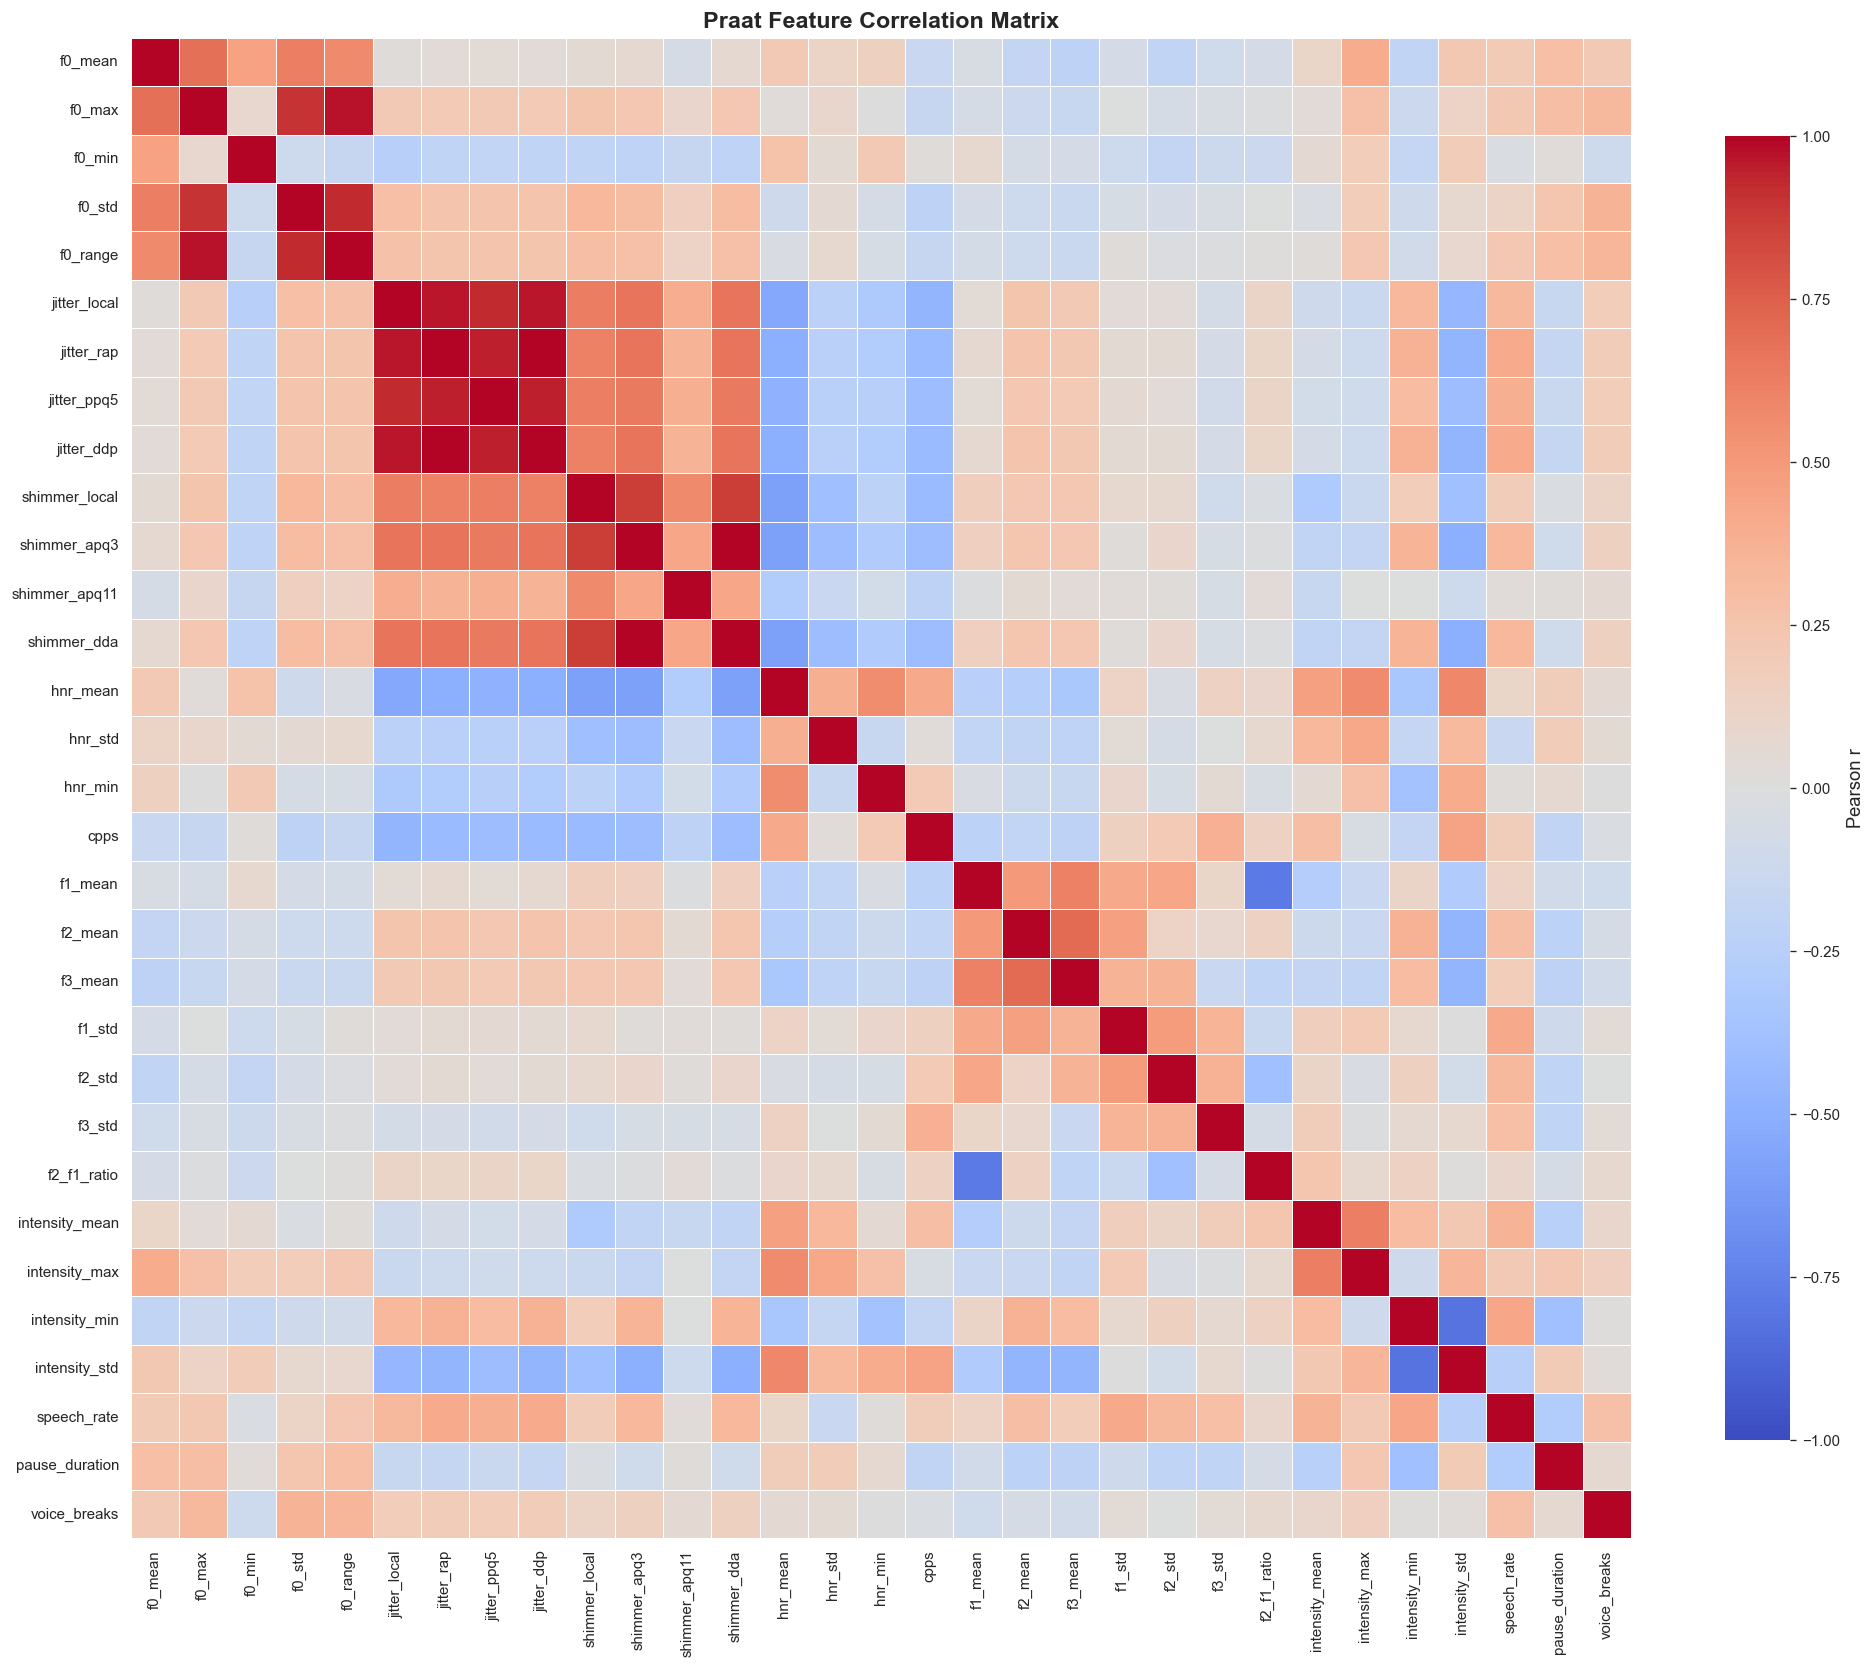


══════════════════════════════════════════════════════════════════════════════
  FEATURE CORRELATION
══════════════════════════════════════════════════════════════════════════════
  Figure .................................. C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\figures\praat_feature_correlation.png


In [6]:
# STAGE 5 - Feature correlation analysis. Which Praat features move together?
# Jitter/shimmer sub-measures and the three formant means are expected to
# correlate strongly since they're different formulas over the same
# underlying signal - this is what tells a reader which features carry
# genuinely independent evidence before Phase 6's Praat pathway treats all
# FEATURE_COLUMNS as independent inputs.
from src.visualization import plot_feature_correlation

correlation_figure = plot_feature_correlation(praat_features, show=True)
print_header("Feature Correlation")
print_kv("Figure", correlation_figure)

In [7]:
# STAGE 6 - Which of those group differences are actually real?
#
# The box plots above are descriptive; this is the test. Kruskal-Wallis H per
# feature across the five groups (non-parametric, because jitter/shimmer and the
# pause/voice-break proxies are bounded and heavily skewed, so ANOVA's normality
# assumption does not hold), Bonferroni-corrected across the FEATURE_COLUMNS features so that
# testing them all at once does not manufacture significance.
#
# The significant rows are the features the discussion section can legitimately
# claim separate severity levels - and they are the ones worth reading first in
# notebooks/05_error_analysis.ipynb and Phase 6's Praat fusion pathway.
from src.praat import praat_group_significance

significance = praat_group_significance(praat_features)

significance_path = config.METRICS_DIR / "praat_significance.csv"
significance.to_csv(significance_path, index=False)

n_sig = int(significance["significant"].sum())

print_header("Kruskal-Wallis Severity Group Significance")
print_kv("Significance table", significance_path)
print_kv("Significant features (p_adj < 0.05)", f"{n_sig} / {len(significance)}")
print_kv("Strongest separator", significance.iloc[0]["feature"])
significance


══════════════════════════════════════════════════════════════════════════════
  KRUSKAL-WALLIS SEVERITY GROUP SIGNIFICANCE
══════════════════════════════════════════════════════════════════════════════
  Significance table ...................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\metrics\praat_significance.csv
  Significant features (p_adj < 0.05) ..... 31 / 31
  Strongest separator ..................... f0_mean


,feature,H,p,p_adj,n_used,significant
0,f0_mean,5134.376588,0.000000e+00,0.000000e+00,21373,True
1,f0_max,4282.357667,0.000000e+00,0.000000e+00,21373,True
2,f0_std,2967.833813,0.000000e+00,0.000000e+00,21373,True
3,f0_range,3733.945704,0.000000e+00,0.000000e+00,21373,True
4,hnr_mean,3290.931236,0.000000e+00,0.000000e+00,21381,True
5,hnr_min,2213.236673,0.000000e+00,0.000000e+00,21381,True
6,pause_duration,7919.422710,0.000000e+00,0.000000e+00,21381,True
7,speech_rate,2956.566742,0.000000e+00,0.000000e+00,21381,True
8,intensity_mean,1814.480597,0.000000e+00,0.000000e+00,21381,True
9,intensity_max,6826.525286,0.000000e+00,0.000000e+00,21381,True
